# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.

![](https:///raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)

## Dataset

Download and acces the dataset through its official [PyTorch `FGVCAircraft` class](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) (by setting its constructor argument `annotation_level` to `'variant'`).

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

# Solution

You can find the solution to this assignment in the following [GitHub repository](https://github.com/mohamadch91/UNIBO_IPCV_Image_classification).
Repository contains the code for both parts of the assignment, also includes all training history, plots, and results. The code is organized in a way that allows you to easily reproduce the results and run your own experiments.


## Import dependencies


In [17]:
# basic dependencies
import copy
import json
import random
import time
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional
# colab
# from google.colab import drive
# ploting and training
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
# confusion matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
# progress bar
from tqdm.notebook import tqdm
# torch modules
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from torch.utils.data import DataLoader, Subset,ConcatDataset
from torchvision import datasets, transforms as T
from torchvision.models import resnet18, ResNet18_Weights


## Runtime settings


In [27]:

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


fix_random(seed=42)

# set device to GPU if available, otherwise CPU
# I used MPS for training
device = "cpu"
if torch.cuda.is_available():
    print("All good, a GPU is available")
    device = torch.device("cuda:0")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    print("Using Apple Silicon GPU through MPS")
    device = torch.device("mps")
else:
    print("Using CPU")
# create a default path for saving data and outputs
# drive.mount('/content/drive',force_remount=True)
# path_default = Path("/content/drive/MyDrive/IPCV_E2/")
path_default = Path(".")



path_data = path_default / Path("data")
path_outputs = path_default / Path("outputs")
path_ckpts = path_default / path_outputs / "ckpts"
path_histories = path_outputs / "histories"
path_plots = path_outputs / "plots"
path_summaries = path_outputs / "summaries"

# check if paths not exist make it
if not path_default.exists():
    path_default.mkdir()
if not path_data.exists():
    path_data.mkdir()
if not path_outputs.exists():
    path_outputs.mkdir()
if not path_ckpts.exists():
    path_ckpts.mkdir()
if not path_histories.exists():
    path_histories.mkdir()
if not path_plots.exists():
    path_plots.mkdir()
if not path_summaries.exists():
    path_summaries.mkdir()    
    
# Global flags to control the flow of the notebook
DOWNLOAD_DATA = True
RUN_TRAINING = True
SHOW_DATASET_PREVIEW = True
SHOW_CONFUSION_MATRIX = False
PIN_MEMORY = torch.cuda.is_available()
# configs for training hyperparams , model architecture and data augmentation
# base config sets for best hyper params of model
cfg = {
    # image, crop and resize sizes
    "resize_size": 256,
    "crop_size": 224,
    "image_size": 224,
    
    # imput configs
    "augmentation": "light",
    "random_erasing": True,
    "dropout": 0.15,
    "mixup_alpha": 0.85,
    "mixup_prob": 0.75,
    "label_smoothing": 0.1,
    
    # model configs
    "channels": [32, 64, 128, 256],
    "use_batch_norm": True,
   
    # resnet specific configs
    "freeze_backbone": False,
    "head_lr": None,

    # optimizer configs
    "lr": 3e-3,
    "wd": 5e-4,
    
    # early stopping configs
    "early_stop_patience": 12,
    "min_delta": 1e-4,
    
    # training configs
    "batch_size": 64,
    "num_epochs": 70,
}

pd.DataFrame.from_dict(cfg, orient="index", columns=["value"])


Using Apple Silicon GPU through MPS


,value
resize_size,256
crop_size,224
image_size,224
augmentation,light
random_erasing,True
dropout,0.15
mixup_alpha,0.85
mixup_prob,0.75
label_smoothing,0.1
channels,"[32, 64, 128, 256]"


## Dataset and transforms

In [28]:
mean_image_net = [0.485, 0.456, 0.406]
std_image_net = [0.229, 0.224, 0.225]


def get_train_transform(cfg: Dict[str, Any]) -> T.Compose:
    if cfg["augmentation"] == "none":
        transform_list = [
            T.Resize((cfg["crop_size"], cfg["crop_size"])),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    elif cfg["augmentation"] == "light":
        transform_list = [
            T.Resize(cfg["resize_size"]),
            T.RandomCrop(cfg["crop_size"]),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    elif cfg["augmentation"] == "strong":
        transform_list = [
            T.RandomResizedCrop(
                cfg["crop_size"],
                scale=(0.88, 1.0),
                ratio=(0.95, 1.05),
            ),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(8),
            T.ColorJitter(
                brightness=0.08,
                contrast=0.08,
                saturation=0.08,
                hue=0.01,
            ),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    elif cfg["augmentation"] == "resnet_strong":
        transform_list = [
            T.RandomResizedCrop(cfg["crop_size"], scale=(0.60, 1.00), ratio=(0.80, 1.20)),
            T.RandomHorizontalFlip(),
            T.RandAugment(num_ops=2, magnitude=9),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    else:
        raise ValueError(f"Unknown augmentation policy: {cfg['augmentation']}")

    if cfg.get("random_erasing", False):
        transform_list.append(T.RandomErasing(p=0.10, scale=(0.02, 0.05)))

    return T.Compose(transform_list)


def get_eval_transform(cfg: Dict[str, Any]) -> T.Compose:
    return T.Compose([
        T.Resize(cfg["resize_size"]),
        T.CenterCrop(cfg["crop_size"]),
        T.ToTensor(),
        T.Normalize(mean_image_net, std_image_net)
    ])
    
def mixup(x, y, num_classes, alpha=0.2, prob=0.5):
    y_onehot = F.one_hot(y, num_classes).float()
    if np.random.rand() > prob or alpha <= 0:
        return x, y_onehot  # skip mixing this batch
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x = lam * x + (1 - lam) * x[idx]
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[idx]
    return x, y_mixed



def get_datasets(cfg: Dict[str, Any]):
    data_train = datasets.FGVCAircraft(
        root=path_data,
        split="train",
        annotation_level="variant",
        transform=get_train_transform(cfg),
        download=DOWNLOAD_DATA,

    )
    data_val = datasets.FGVCAircraft(
        root=path_data,
        split="val",
        annotation_level="variant",
        transform=get_eval_transform(cfg),
        download=DOWNLOAD_DATA
    )
    data_test = datasets.FGVCAircraft(
        root=path_data,
        split="test",
        annotation_level="variant",
        transform=get_eval_transform(cfg),
        download=DOWNLOAD_DATA
    )

    classes = data_train.classes



    return data_train, data_val, data_test, classes


def get_loaders(data_train, data_val, data_test, cfg: Dict[str, Any]):
    loader_train = DataLoader(
        data_train,
        batch_size=cfg["batch_size"],
        shuffle=True,
        pin_memory=PIN_MEMORY
    )
    loader_val = DataLoader(
        data_val,
        batch_size=cfg["batch_size"],
        shuffle=False,
        pin_memory=PIN_MEMORY
    )
    loader_test = DataLoader(
        data_test,
        batch_size=cfg["batch_size"],
        shuffle=False,
        pin_memory=PIN_MEMORY
    )

    return loader_train, loader_val, loader_test


## Show dataset preview

# Train samples = 3334
# Val samples = 3333
# Test samples = 3333
# Classes = 100


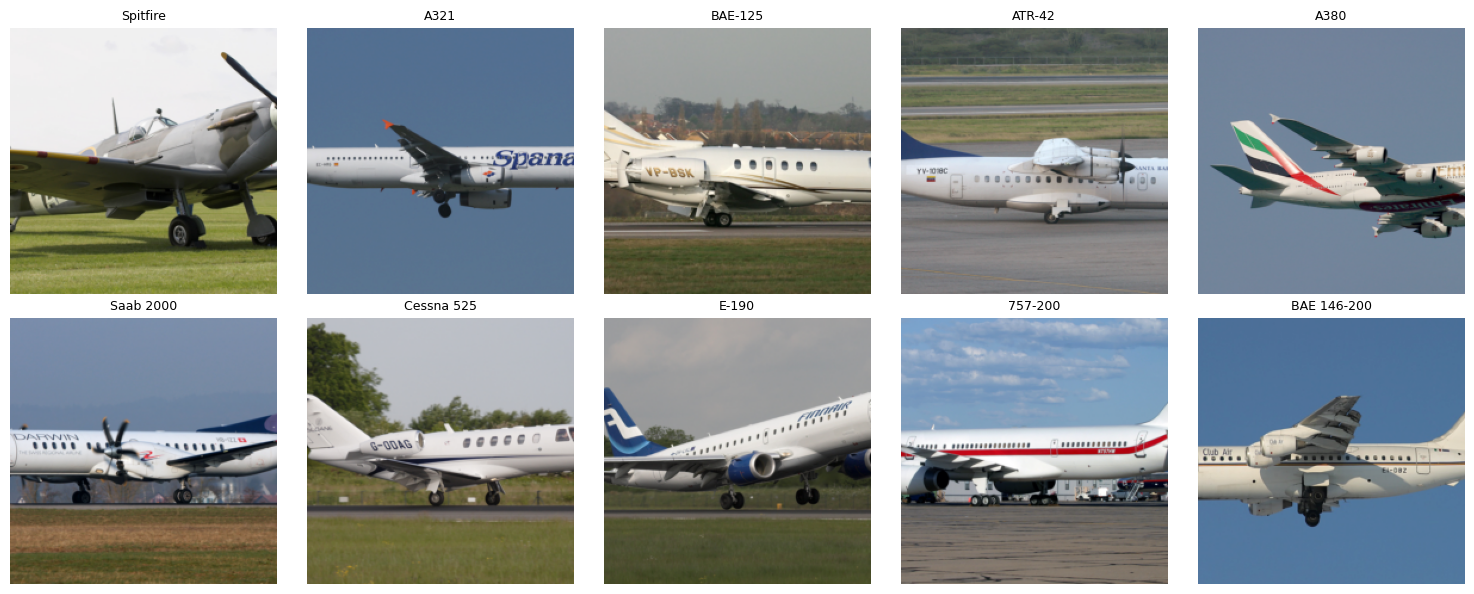

In [29]:
class NormalizeInverse(T.Normalize):
    def __init__(self, mean: List[float], std: List[float]) -> None:
        """Reconstructs the images in the input domain by inverting
        the normalization transformation.

        Args:
            mean: the mean used to normalize the images.
            std: the standard deviation used to normalize the images.
        """
        mean = torch.as_tensor(mean)
        std = torch.as_tensor(std)
        std_inv = 1 / (std + 1e-7)
        mean_inv = -mean * std_inv
        super().__init__(mean=mean_inv, std=std_inv)

    def __call__(self, tensor):
        return super().__call__(tensor.clone())


def show_grid(dataset, classes: List[str], process: Callable = None) -> None:
    """Shows a grid with random images taken from the dataset."""
    fig = plt.figure(figsize=(15, 6))
    indices_random = np.random.randint(10, size=10, high=len(dataset))

    for count, idx in enumerate(indices_random):
        fig.add_subplot(2, 5, count + 1)
        image, label = dataset[idx]
        title = classes[label]
        plt.title(title, fontsize=9)
        image_processed = process(image) if process is not None else image
        plt.imshow(T.ToPILImage()(image_processed))
        plt.axis("off")

    plt.tight_layout()
    plt.show()


denormalize = NormalizeInverse(mean_image_net, std_image_net)

if SHOW_DATASET_PREVIEW:

    data_train_preview, data_val_preview, data_test_preview, classes = get_datasets(cfg)
    print(f"# Train samples = {len(data_train_preview)}")
    print(f"# Val samples = {len(data_val_preview)}")
    print(f"# Test samples = {len(data_test_preview)}")
    print(f"# Classes = {len(classes)}")
    show_grid(data_val_preview, classes, process=denormalize)


## Training functions

this section contains the functions which are used to calculate accuracy,loss,
model parameteres, get optimizer, scheduler, and a class Trainer for training the model.


In [30]:
def ncorrect(scores, y):
    y_hat = torch.argmax(scores, -1)
    return (y_hat == y).sum()


def accuracy(scores, y):
    correct = ncorrect(scores, y)
    return correct.true_divide(y.shape[0])


def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def get_optimizer(model: nn.Module, cfg: Dict[str, Any]):
    params = []

    if cfg.get("head_lr") is not None:
        backbone_params = []
        head_params = []
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if name.startswith("fc") or name.startswith("classifier"):
                head_params.append(p)
            else:
                backbone_params.append(p)

        if len(backbone_params) > 0:
            params.append({"params": backbone_params, "lr": cfg["lr"]})
        if len(head_params) > 0:
            params.append({"params": head_params, "lr": cfg["head_lr"]})
    else:
        params = [p for p in model.parameters() if p.requires_grad]

    return AdamW(params, lr=cfg["lr"], weight_decay=cfg["wd"])


class Trainer:
    def __init__(
            self,
            model: nn.Module,
            train_loader: DataLoader,
            val_loader: DataLoader,
            device: torch.device,
            cfg: Dict[str, Any]
        ) -> None:
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.cfg = cfg
        self.num_epochs = cfg["num_epochs"]

        self.model = model.to(device)
        self.optimizer = get_optimizer(self.model, cfg)
        max_lr = [group["lr"] for group in self.optimizer.param_groups]
        print(f"Max learning rates for OneCycleLR: {max_lr}")
        self.scheduler = OneCycleLR(
            self.optimizer,
            max_lr=max_lr,
            total_steps=self.num_epochs * len(train_loader)
        )

        
        self.step = 0
        self.best_acc = 0.0
        self.best_epoch = -1
        self.best_params = copy.deepcopy(self.model.state_dict())
        
        
        # Early stopping
        self.best_val_acc = float(-1)
        self.patience = self.cfg.get("early_stop_patience", 20)          # stop after 20 epochs without val loss improvement
        self.min_delta = self.cfg.get("min_delta", 1e-4)      # minimum decrease in val loss to count as improvement
        self.epochs_without_improvement = 0


        self.history = []
        self.ckpt_path = path_ckpts / f"{cfg['run_name']}.pt"

    def eval(self, loader, return_cm=False):
        self.model.eval()

        total_loss = 0
        total_samples = 0
        total_acc = 0

        if return_cm:
            all_preds = []
            all_labels = []

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                scores = self.model(imgs)
                loss = F.cross_entropy(scores, labels, reduction="sum")

                total_loss += loss.item()
                total_samples += imgs.size(0)
                total_acc += ncorrect(scores, labels).item()

                if return_cm:
                    preds = scores.argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

        total_loss /= total_samples
        total_acc /= total_samples

        if return_cm:
            cm = confusion_matrix(all_labels, all_preds)
            return total_loss, total_acc, cm

        return total_loss, total_acc

    def train(self) -> None:
        for e in tqdm(range(self.num_epochs), desc="Epoch"):
            print(f"\nTraining epoch {e + 1}/{self.num_epochs}")

            self.model.train()

            train_loss = 0.0
            train_acc = 0
            train_samples = 0

            pbar = tqdm(self.train_loader, desc=f"Epoch {e + 1}/{self.num_epochs}")

            for imgs, labels in pbar:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                imgs_mixed, labels_mixed = mixup(
                    imgs,
                    labels,
                    self.cfg.get("num_classes", 100),
                    alpha=self.cfg.get("mixup_alpha", 0.2),
                    prob=self.cfg.get("mixup_prob", 0.5),
                )

                scores = self.model(imgs_mixed)

                log_probs = F.log_softmax(scores, dim=1)

                if self.cfg.get("label_smoothing", 0.0) > 0:
                    num_classes = scores.shape[1]
                    smoothing = self.cfg["label_smoothing"]
                    labels_mixed = (
                        labels_mixed * (1 - smoothing)
                        + smoothing / num_classes
                    )

                loss = -(labels_mixed * log_probs).sum(dim=1).mean()

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), max_norm=5.0
                )
                self.optimizer.step()
                self.scheduler.step()

                train_loss += loss.item() * imgs.size(0)
                train_acc += ncorrect(scores, labels).item()
                train_samples += imgs.size(0)

                pbar.set_postfix(loss=f"{loss.item():.4f}")

                self.step += 1

            train_loss /= train_samples
            train_acc /= train_samples

            val_loss, val_acc = self.eval(self.val_loader)

            current_lr = self.optimizer.param_groups[0]["lr"]

            self.history.append({
                "epoch": e + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "lr": current_lr,
            })

            print(
                f"Epoch {e + 1:03d}/{self.num_epochs} | "
                f"LR: {current_lr:.2e} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

            # ----------------------------------------------------
            # Save best model according to validation accuracy
            # ----------------------------------------------------
            if val_acc > self.best_acc:
                self.best_acc = val_acc
                self.best_epoch = e + 1
                self.best_params = copy.deepcopy(self.model.state_dict())
                torch.save(self.best_params, self.ckpt_path)

                print(f"✓ Saved new best model (val_acc={val_acc:.4f})")

            # ----------------------------------------------------
            # Early stopping according to validation accuracy
            # ----------------------------------------------------
            if val_acc > self.best_val_acc + self.min_delta:
                self.best_val_acc = val_acc
                self.epochs_without_improvement = 0
            else:
                self.epochs_without_improvement += 1

                print(
                    f"Validation accuracy did not improve "
                    f"({self.epochs_without_improvement}/{self.patience})"
                )

                if self.epochs_without_improvement >= self.patience:
                    print("\nEarly stopping triggered.")
                    print(
                        f"Best validation accuracy: {self.best_acc:.4f} "
                        f"(epoch {self.best_epoch})"
                    )
                    break
        
        
            
        if self.best_params is not None:
            self.model.load_state_dict(self.best_params)
            
        print(
            f"\nTraining complete. "
            f"Best validation accuracy: {self.best_acc:.4f} "
            f"at epoch {self.best_epoch}."
        )
        
             

            

## Run training
This section contains the code to run the training of any model and plot the training curves. and summary of the result to table, csv, json.

In [31]:

def plot_confusion_matrix(cm, class_names=None, normalize=False, save_path= None):
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm = cm.clip(min=0)

    fig, ax = plt.subplots(figsize=(30, 30))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
        
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        colorbar=True,
        include_values=False,
        values_format=".2f" if normalize else "d"
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
def run_experiment(cfg_exp: Dict[str, Any], get_model_fn: Callable):
    fix_random(seed=42)

    data_train, data_val, data_test, classes = get_datasets(cfg_exp)   
    loader_train, loader_val, loader_test = get_loaders(data_train, data_val, data_test, cfg_exp)
    

    model = get_model_fn(len(classes), cfg_exp)
    print(f"Run name = {cfg_exp['run_name']}")
    print(f"Total parameters = {count_parameters(model):,}")
    print(f"Trainable parameters = {count_parameters(model, trainable_only=True):,}")

    trainer = Trainer(
        model,
        loader_train,
        loader_val,
        device,
        cfg_exp
    )

    start_time = time.time()
    trainer.train()
    elapsed = (time.time() - start_time) / 60

    if SHOW_CONFUSION_MATRIX:
        test_loss, test_acc,cm = trainer.eval(loader_test,True)
        plot_confusion_matrix(
        cm,
        class_names=data_train.classes,
        normalize=True,
        save_path = path_plots / (cfg_exp["run_name"] + "_conf.png")
    )
    else:
        test_loss, test_acc = trainer.eval(loader_test)
        
    history = pd.DataFrame(trainer.history)
    history.to_csv(path_histories / f"{cfg_exp['run_name']}.csv", index=False)

    result = {
        "run_name": cfg_exp["run_name"],
        "best_val_acc": trainer.best_acc,
        "best_epoch": trainer.best_epoch,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "elapsed_min": elapsed,
        "total_parameters": count_parameters(trainer.model),
        "trainable_parameters": count_parameters(trainer.model, trainable_only=True),
        "cfg": copy.deepcopy(cfg_exp),
        "history": history
    }

    result_to_save = copy.deepcopy(result)
    result_to_save.pop("history")
    with open(path_summaries / f"{cfg_exp['run_name']}_summary.json", "w") as f:
        json.dump(result_to_save, f, indent=2)

    print(f"Best val acc = {trainer.best_acc:.3f}")
    print(f"Test acc = {test_acc:.3f}")

    return result


def results_to_table(results: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for run_name, result in results.items():
        rows.append({
            "run_name": run_name,
            "best_val_acc": result["best_val_acc"],
            "test_acc": result["test_acc"],
            "test_loss": result["test_loss"],
            "best_epoch": result["best_epoch"],
            "augmentation": result["cfg"]["augmentation"],
            "lr": result["cfg"]["lr"],
            "head_lr": result["cfg"].get("head_lr"),
            "wd": result["cfg"]["wd"],
            "dropout": result["cfg"].get("dropout"),
            "label_smoothing": result["cfg"].get("label_smoothing"),
            "freeze_backbone": result["cfg"].get("freeze_backbone"),
            "trainable_parameters": result["trainable_parameters"]
        })

    table = pd.DataFrame(rows)
    if len(table) > 0:
        table = table.sort_values("test_acc", ascending=False).reset_index(drop=True)
    return table


def plot_results(results: Dict[str, Dict[str, Any]], save_path: Path = None) -> None:
 
    _, ax = plt.subplots(1, 2, figsize=(20, 12))

    for run_name, result in results.items():
        history = result["history"]
        ax[0].plot(history["epoch"], history["train_acc"], label=f"{run_name} train")
        ax[1].plot(history["epoch"], history["val_acc"], label=f"{run_name} val")

    ax[0].set_title("Training accuracy")
    ax[1].set_title("Validation accuracy")
    for axis in ax:
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Accuracy")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


# Custom CNN model

This is custom low level CNN model which uses residual blocks and other techniques to improve the performance of the model. The model is designed to be trained from scratch on the FGVCAircraft dataset.


In [32]:
class BasicBlock(nn.Module):
    """
    A standard ResNet block with a skip connection.
    """
    def __init__(self, in_channels, out_channels, stride=1, use_batch_norm=True):
        super().__init__()
        self.use_batch_norm = use_batch_norm
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=not use_batch_norm)
        if use_batch_norm:
            self.bn1 = nn.BatchNorm2d(out_channels)
            
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=not use_batch_norm)
        if use_batch_norm:
            self.bn2 = nn.BatchNorm2d(out_channels)
            
        # The shortcut matches dimensions if stride > 1 or channel sizes differ
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            shortcut_modules = [nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=not use_batch_norm)]
            if use_batch_norm:
                shortcut_modules.append(nn.BatchNorm2d(out_channels))
            self.shortcut = nn.Sequential(*shortcut_modules)
            
    def forward(self, x):
        out = self.conv1(x)
        if self.use_batch_norm: out = self.bn1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        if self.use_batch_norm: out = self.bn2(out)
        
        # Add the skip connection before the final ReLU
        out += self.shortcut(x)
        out = F.relu(out)
        return out
class AircraftCNN(nn.Module):
    """
    Custom ResNet-like CNN built entirely from scratch.
    """
    def __init__(self, num_classes: int, cfg: Dict[str, Any]):
        super().__init__()
        
        self.use_batch_norm = cfg.get("use_batch_norm", True)
        channels = cfg["channels"]
        self.in_channels = channels[0]
        
        # Initial Downsampling Block
        modules = [
            nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=not self.use_batch_norm)
        ]
        if self.use_batch_norm:
            modules.append(nn.BatchNorm2d(self.in_channels))
        modules.append(nn.ReLU())
        modules.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        
        self.conv1 = nn.Sequential(*modules)
        
        # Residual Blocks Stages
        blocks = []
        for i, out_channels in enumerate(channels):
            # Downsample on the first block of each stage except the first stage
            stride = 1 if i == 0 else 2
            blocks.append(BasicBlock(self.in_channels, out_channels, stride=stride, use_batch_norm=self.use_batch_norm))
            blocks.append(BasicBlock(out_channels, out_channels, stride=1, use_batch_norm=self.use_batch_norm))
            self.in_channels = out_channels
            
        self.features = nn.Sequential(*blocks)
        
        # Classifier Head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(cfg.get("dropout", 0.0)),
            nn.Linear(self.in_channels, num_classes)
        )
        
        # Initialize weights properly
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.features(x)
        x = self.classifier(x)
        return x
def get_custom_cnn(num_classes: int, cfg: Dict[str, Any]) -> nn.Module:
    return AircraftCNN(num_classes, cfg)

## Best model


In [33]:
cfg_part1 = copy.deepcopy(cfg)
cfg_part1["run_name"] = "best_model"
pd.DataFrame.from_dict(cfg_part1, orient="index", columns=["value"])


,value
resize_size,256
crop_size,224
image_size,224
augmentation,light
random_erasing,True
dropout,0.15
mixup_alpha,0.85
mixup_prob,0.75
label_smoothing,0.1
channels,"[32, 64, 128, 256]"


### Results

Running part 1 experiments...
Run name = best_model
Total parameters = 2,824,580
Trainable parameters = 2,824,580
Max learning rates for OneCycleLR: [0.003]


Epoch:   0%|          | 0/70 [00:00<?, ?it/s]


Training epoch 1/70


Epoch 1/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 001/70 | LR: 1.36e-04 | Train Loss: 4.6020 | Train Acc: 0.0141 | Val Loss: 4.5638 | Val Acc: 0.0171
✓ Saved new best model (val_acc=0.0171)

Training epoch 2/70


...

Epoch 068/70 | LR: 1.21e-05 | Train Loss: 2.3732 | Train Acc: 0.5579 | Val Loss: 1.7413 | Val Acc: 0.5605
✓ Saved new best model (val_acc=0.5605)

Training epoch 69/70


Epoch 69/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 069/70 | LR: 2.98e-06 | Train Loss: 2.2615 | Train Acc: 0.5066 | Val Loss: 1.7824 | Val Acc: 0.5530
Validation accuracy did not improve (1/12)

Training epoch 70/70


Epoch 70/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 070/70 | LR: 1.31e-08 | Train Loss: 2.3934 | Train Acc: 0.5030 | Val Loss: 1.7976 | Val Acc: 0.5518
Validation accuracy did not improve (2/12)

Training complete. Best validation accuracy: 0.5605 at epoch 68.


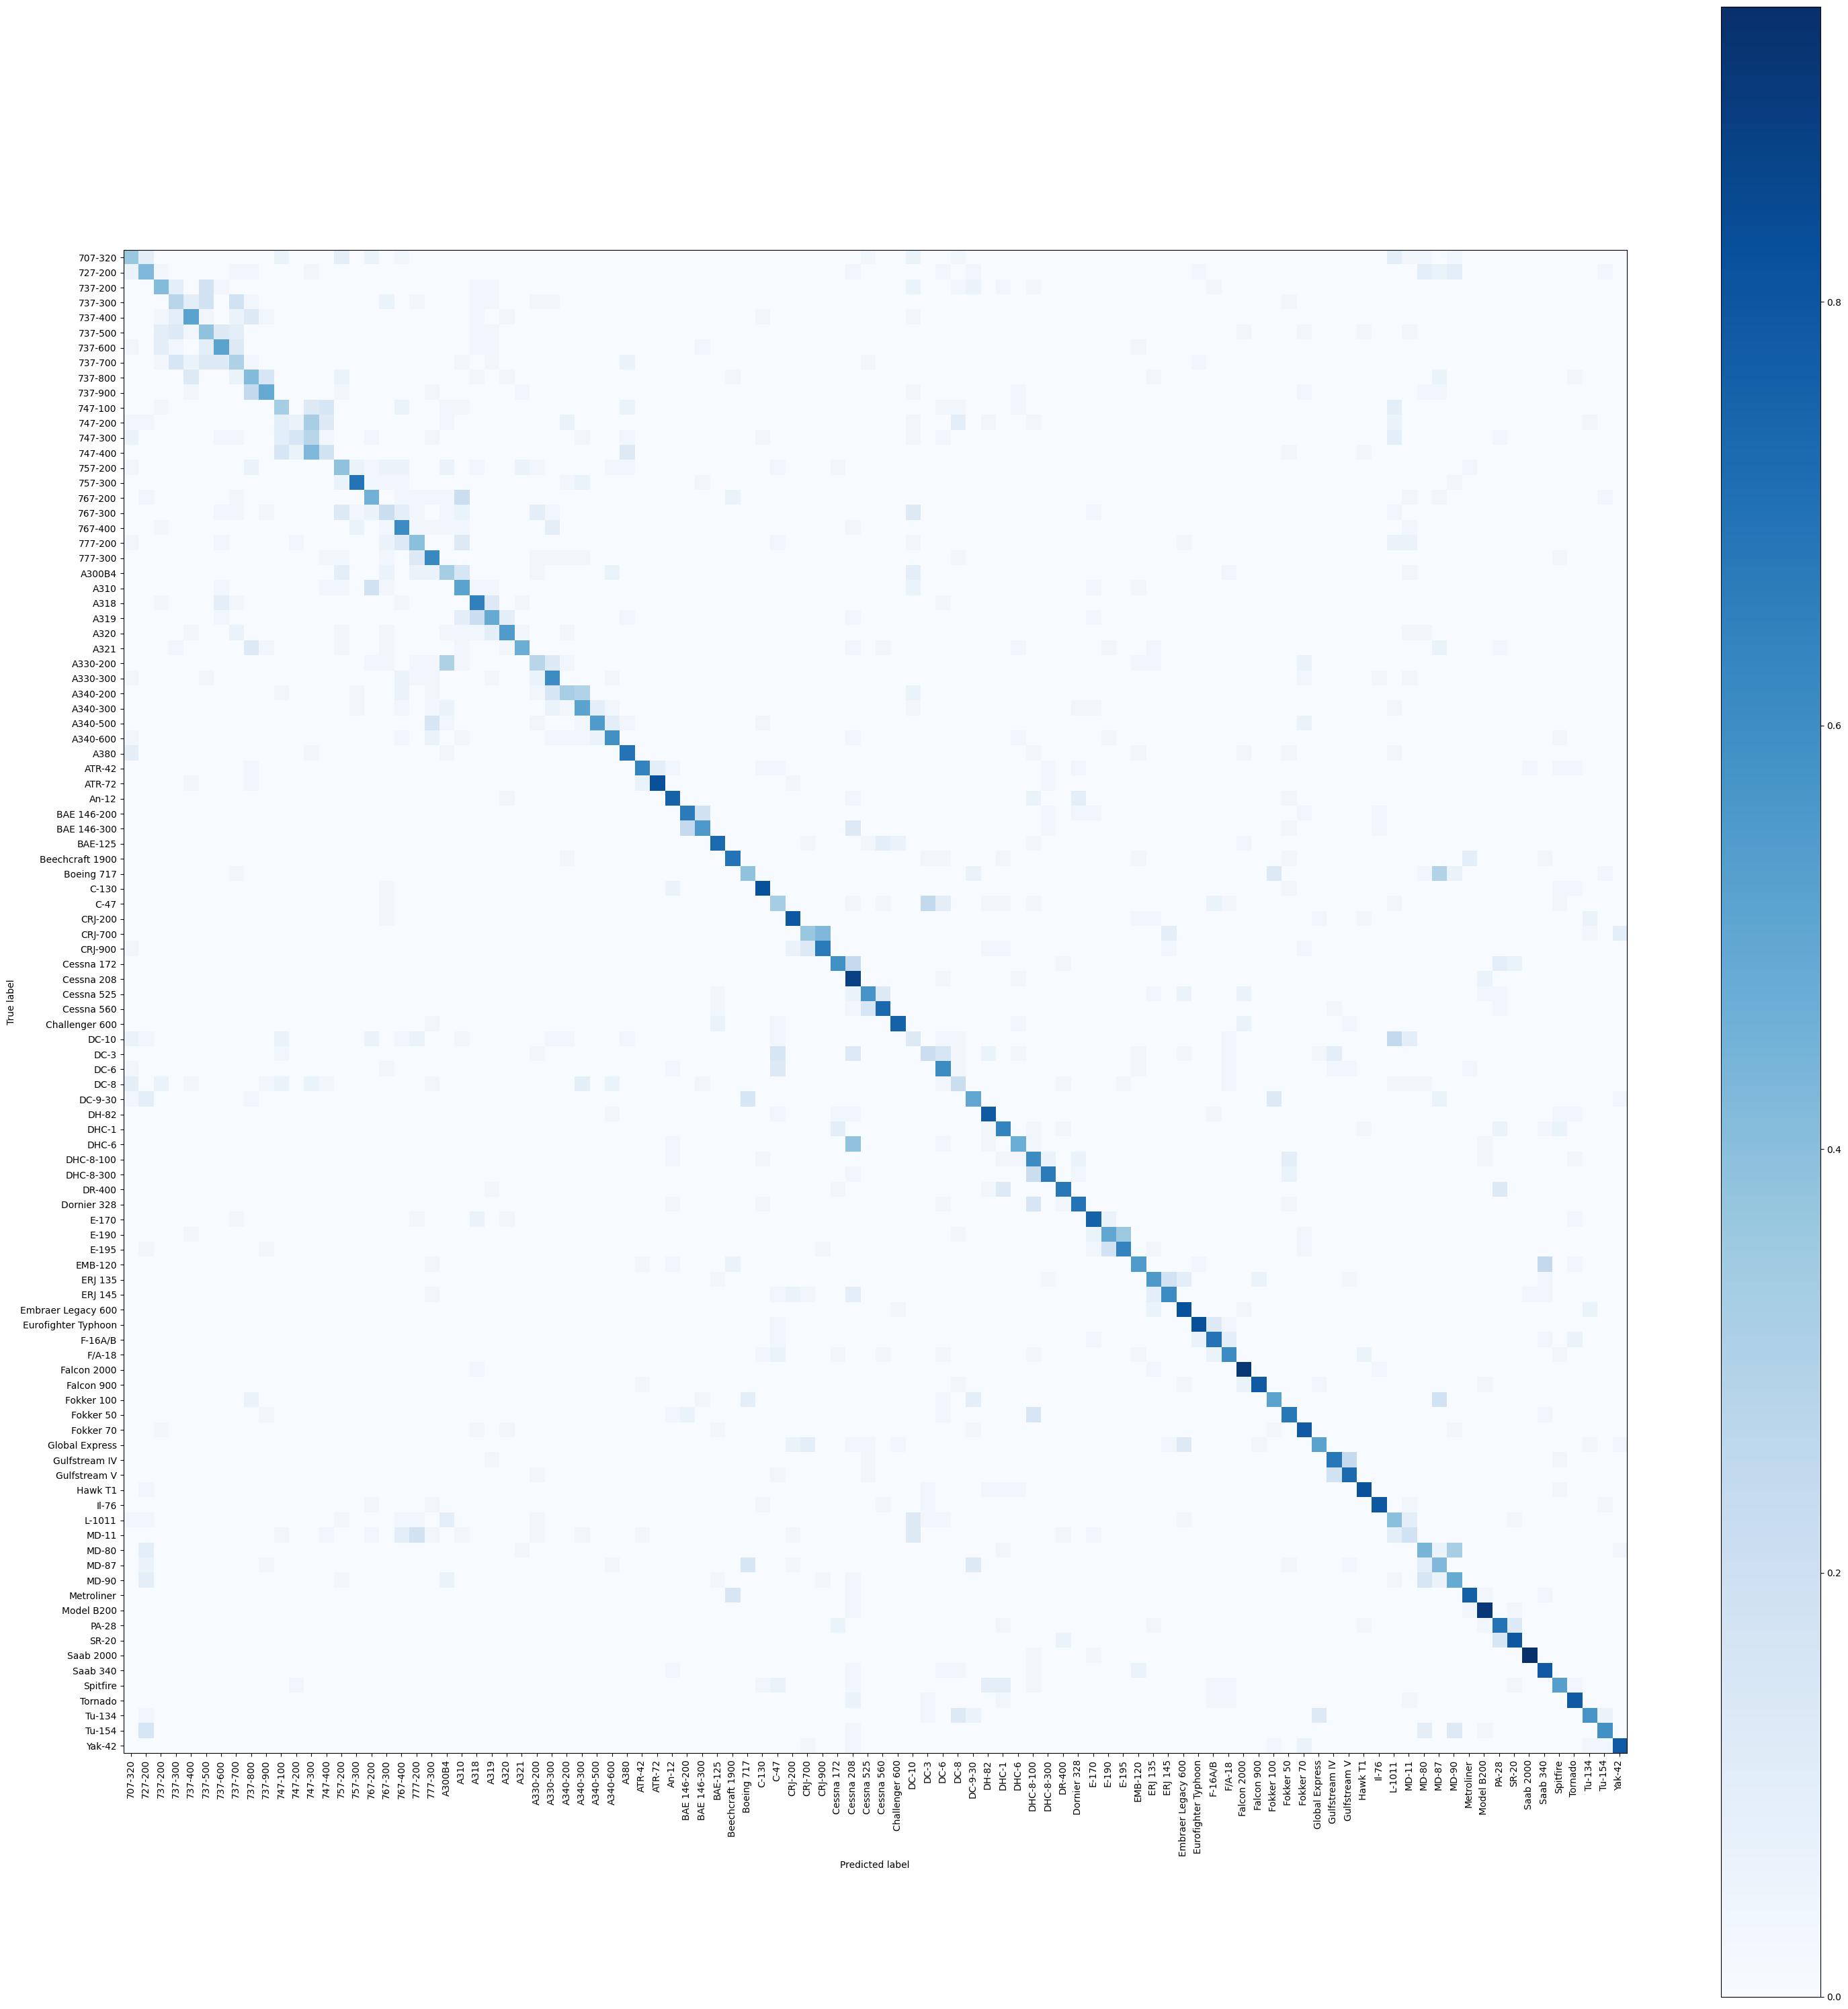

Best val acc = 0.560
Test acc = 0.566


,run_name,best_val_acc,test_acc,test_loss,best_epoch,augmentation,lr,head_lr,wd,dropout,label_smoothing,freeze_backbone,trainable_parameters
0,best_model,0.560456,0.566157,1.716769,68,light,0.003,None,0.0005,0.15,0.1,False,2824580


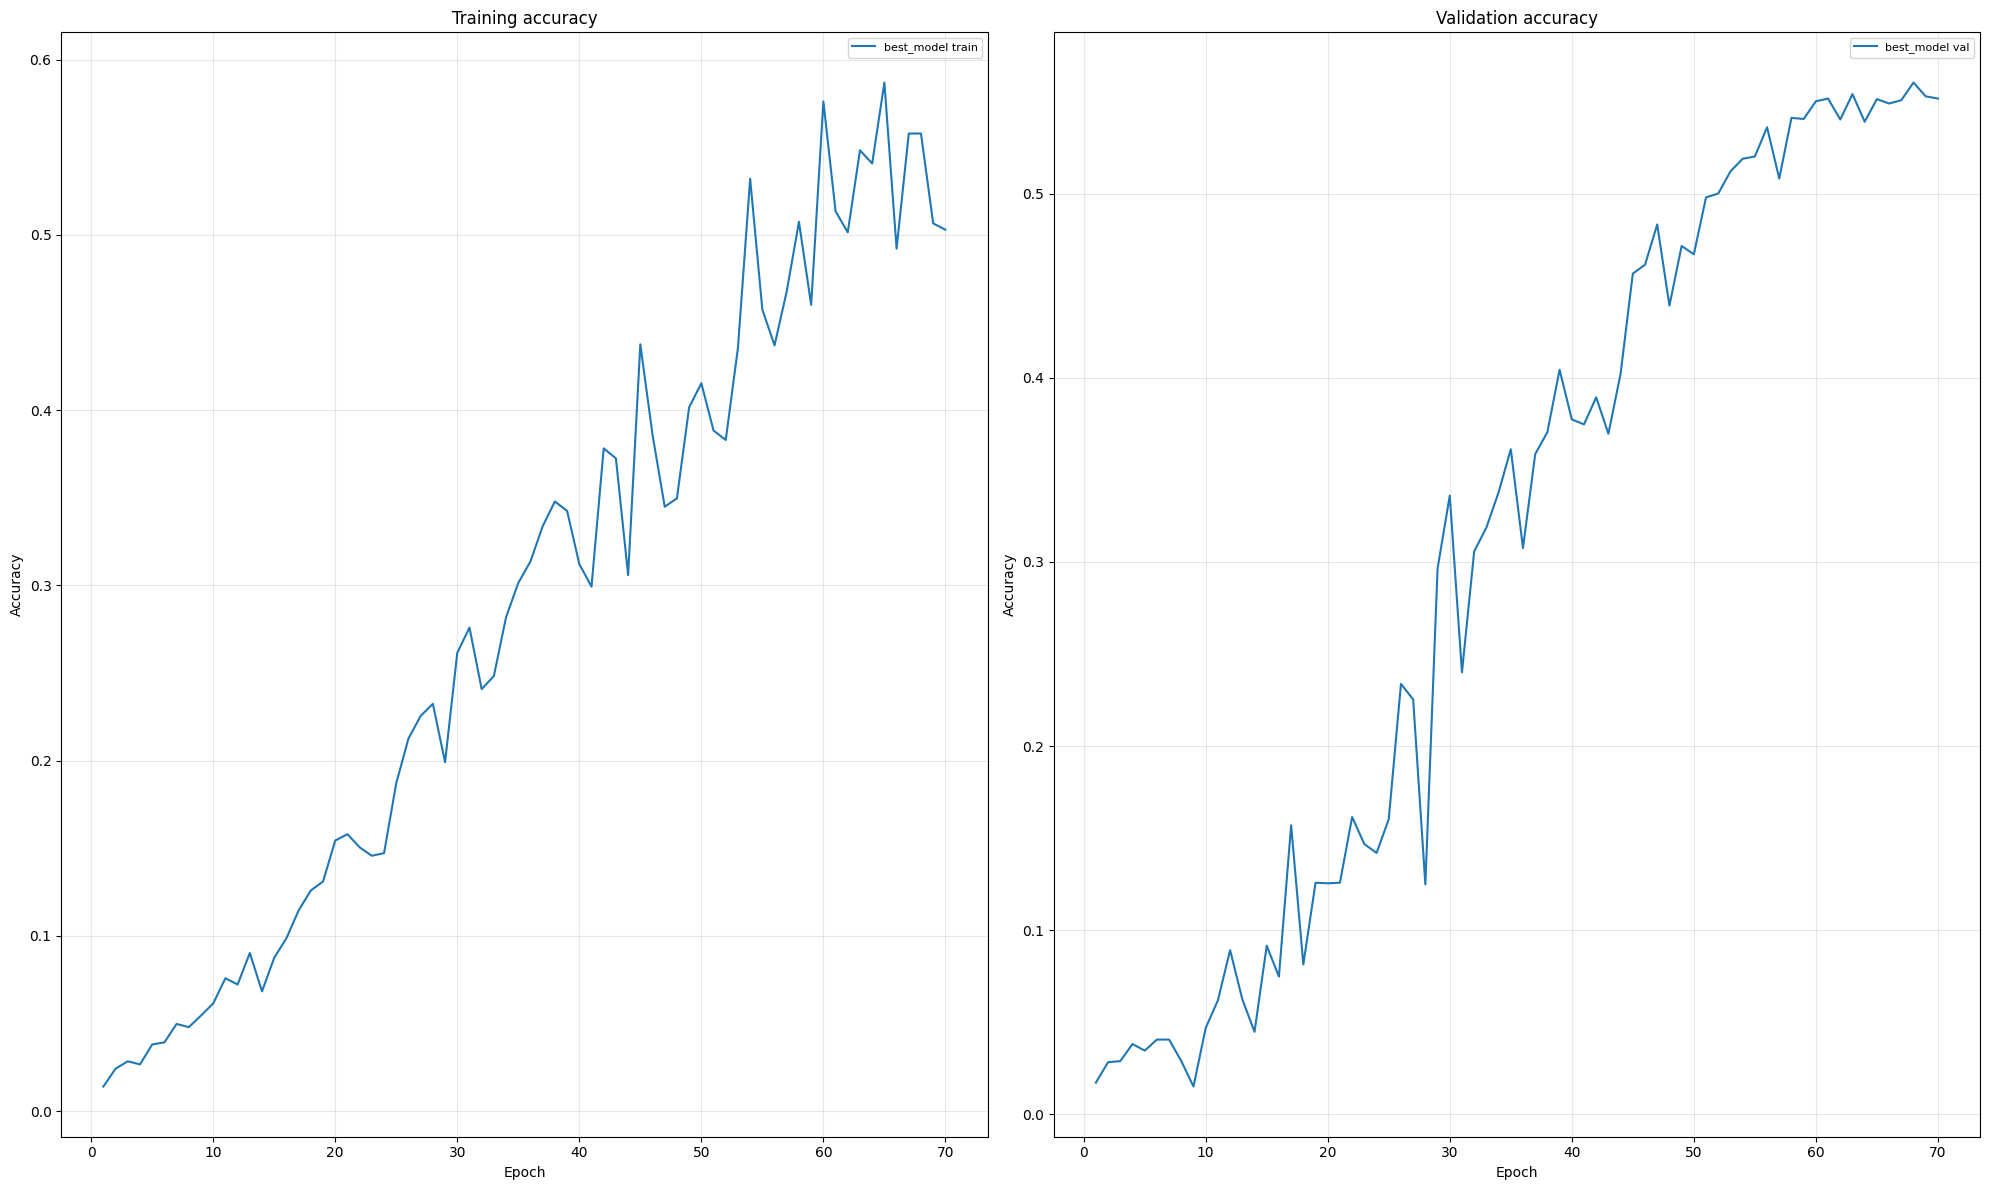

In [34]:
part1_results = {}
print("Running part 1 experiments...")
SHOW_CONFUSION_MATRIX = True
if RUN_TRAINING:
    part1_results[cfg_part1["run_name"]] = run_experiment(cfg_part1, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_part1["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")


### Explanation of the results

## Ablation study
In this section we will show how the performance of the best model drops when we remove some of its components. We will do this by running the same training procedure as before, but with different hyperparameters.
these hyperparameters are:

- removing data augmentation
- make augmentation heavy
- removing mixup
- removing label smoothing
- removing dropout
- increasing the dropout
- removeing batch normalization
- decreasing the learning rate
- removing random erasing

And finally we will go through our journy of finding the best model with all of the running experiments and their results.
  

### Remove augmentation

In [42]:
SHOW_CONFUSION_MATRIX = False
cfg_no_aug = copy.deepcopy(cfg_part1)
cfg_no_aug["run_name"] = "best_model_no_augmentation"
cfg_no_aug["augmentation"] = "none"
pd.DataFrame.from_dict(cfg_no_aug, orient="index", columns=["value"])


,value
resize_size,256
crop_size,224
image_size,224
augmentation,none
random_erasing,True
dropout,0.15
mixup_alpha,0.85
mixup_prob,0.75
label_smoothing,0.1
channels,"[32, 64, 128, 256]"


#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_no_aug["run_name"]] = run_experiment(cfg_no_aug, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_no_aug["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Make augmentation heavy

In [ ]:
cfg_strong_aug = copy.deepcopy(cfg_part1)
cfg_strong_aug["run_name"] = "best_model_strong_augmentation"
cfg_strong_aug["augmentation"] = "strong"
pd.DataFrame.from_dict(cfg_strong_aug, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_strong_aug["run_name"]] = run_experiment(cfg_strong_aug, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_strong_aug["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Remove mixup

In [ ]:
cfg_no_mixup = copy.deepcopy(cfg_part1)
cfg_no_mixup["run_name"] = "best_model_no_mixup"
cfg_no_mixup["mixup_alpha"] = 0
cfg_no_mixup["mixup_prob"] = 0
pd.DataFrame.from_dict(cfg_no_mixup, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_no_mixup["run_name"]] = run_experiment(cfg_no_mixup, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_no_mixup["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Remove label smoothing

In [ ]:
cfg_no_label_smoothing = copy.deepcopy(cfg_part1)
cfg_no_label_smoothing["run_name"] = "best_model_no_label_smoothing"
cfg_no_label_smoothing["label_smoothing"] = 0
pd.DataFrame.from_dict(cfg_no_label_smoothing, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_no_label_smoothing["run_name"]] = run_experiment(cfg_no_label_smoothing, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_no_label_smoothing["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Remove dropout

In [ ]:
cfg_no_dropout = copy.deepcopy(cfg_part1)
cfg_no_dropout["run_name"] = "best_model_no_dropout"
cfg_no_dropout["dropout"] = 0
pd.DataFrame.from_dict(cfg_no_dropout, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_no_dropout["run_name"]] = run_experiment(cfg_no_dropout, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_no_dropout["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Increase dropout

In [ ]:
cfg_high_dropout = copy.deepcopy(cfg_part1)
cfg_high_dropout["run_name"] = "best_model_high_dropout"
cfg_high_dropout["dropout"] = 0.7
pd.DataFrame.from_dict(cfg_high_dropout, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_high_dropout["run_name"]] = run_experiment(cfg_high_dropout, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_high_dropout["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Remove Batch Normalization

In [ ]:
cfg_no_batch_norm = copy.deepcopy(cfg_part1)
cfg_no_batch_norm["run_name"] = "best_model_no_batch_norm"
cfg_no_batch_norm["batch_norm"] = False
pd.DataFrame.from_dict(cfg_no_batch_norm, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_no_batch_norm["run_name"]] = run_experiment(cfg_no_batch_norm, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_no_batch_norm["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Decrease learning rate

In [ ]:
cfg_low_lr = copy.deepcopy(cfg_part1)
cfg_low_lr["run_name"] = "best_model_low_learning_rate"
cfg_low_lr["lr"] = 1e-4
pd.DataFrame.from_dict(cfg_low_lr, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_low_lr["run_name"]] = run_experiment(cfg_low_lr, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_low_lr["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



### Remove random erasing

In [ ]:
cfg_remove_random_erasing = copy.deepcopy(cfg_part1)
cfg_remove_random_erasing["run_name"] = "best_model_no_random_erasing"
cfg_remove_random_erasing["random_erasing"] = False
pd.DataFrame.from_dict(cfg_remove_random_erasing, orient="index", columns=["value"])

#### Results

In [ ]:
if RUN_TRAINING:
    part1_results[cfg_remove_random_erasing["run_name"]] = run_experiment(cfg_remove_random_erasing, get_custom_cnn)
    display(results_to_table(part1_results))
    plot_results(part1_results, save_path=path_plots / (cfg_remove_random_erasing["run_name"] + ".png"))

else:
    print("RUN_TRAINING is False")

#### Explanation of the results



## Complete list of experiments and their results

# Part 2

This part uses the PyTorch ResNet-18 model with ImageNet-1K V1 weights


## Load pretrained ResNet-18 model

In [35]:
def set_requires_grad(layer: torch.nn.Module, train: bool) -> None:
    """Sets the requires_grad attribute to True or False for each parameter within a layer.

    Args:
        layer: the layer to freeze.
        train: if true, train the layer.
    """
    for p in layer.parameters():
        p.requires_grad = train


def get_resnet18_model(num_classes: int, cfg: Dict[str, Any]) -> nn.Module:
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)

    classifier = nn.Sequential(
        nn.Dropout(cfg["dropout"]),
        nn.Linear(model.fc.in_features, num_classes)
    )
    model.fc = classifier

    if cfg["freeze_backbone"]:
        set_requires_grad(model.conv1, False)
        set_requires_grad(model.bn1, False)
        set_requires_grad(model.layer1, False)
        set_requires_grad(model.layer2, False)
        set_requires_grad(model.layer3, False)
        set_requires_grad(model.layer4, False)

    return model


## Part 2A: ResNet-18 with Part 1 hyperparameters

The training hyperparameters are copied from the best model from part 1. The only necessary architecture change is replacing the final classifier of ResNet-18.
I will try both freezing the backbone and training the whole model, and compare the results.


### Freeze backbone

In [36]:
cfg_resnet_same_freeze = copy.deepcopy(cfg_part1)
cfg_resnet_same_freeze["run_name"] = "resnet18_same_hyperparameters_freeze_backbone"
cfg_resnet_same_freeze["dropout"] = 0.0
cfg_resnet_same_freeze["freeze_backbone"] = True
cfg_resnet_same_freeze["head_lr"] = None

pd.DataFrame.from_dict(cfg_resnet_same_freeze, orient="index", columns=["value"])


,value
resize_size,256
crop_size,224
image_size,224
augmentation,light
random_erasing,True
dropout,0.0
mixup_alpha,0.85
mixup_prob,0.75
label_smoothing,0.1
channels,"[32, 64, 128, 256]"


### Result

Run name = resnet18_same_hyperparameters_freeze_backbone
Total parameters = 11,227,812
Trainable parameters = 51,300
Max learning rates for OneCycleLR: [0.003]


Epoch:   0%|          | 0/70 [00:00<?, ?it/s]


Training epoch 1/70


Epoch 1/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 001/70 | LR: 1.36e-04 | Train Loss: 4.7127 | Train Acc: 0.0105 | Val Loss: 4.6273 | Val Acc: 0.0144
✓ Saved new best model (val_acc=0.0144)

Training epoch 2/70


...

Epoch 068/70 | LR: 1.21e-05 | Train Loss: 2.8254 | Train Acc: 0.4466 | Val Loss: 2.6933 | Val Acc: 0.3444
✓ Saved new best model (val_acc=0.3444)

Training epoch 69/70


Epoch 69/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 069/70 | LR: 2.98e-06 | Train Loss: 2.7172 | Train Acc: 0.4070 | Val Loss: 2.7091 | Val Acc: 0.3429
Validation accuracy did not improve (1/12)

Training epoch 70/70


Epoch 70/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 070/70 | LR: 1.31e-08 | Train Loss: 2.8309 | Train Acc: 0.4208 | Val Loss: 2.7147 | Val Acc: 0.3414
Validation accuracy did not improve (2/12)

Training complete. Best validation accuracy: 0.3444 at epoch 68.


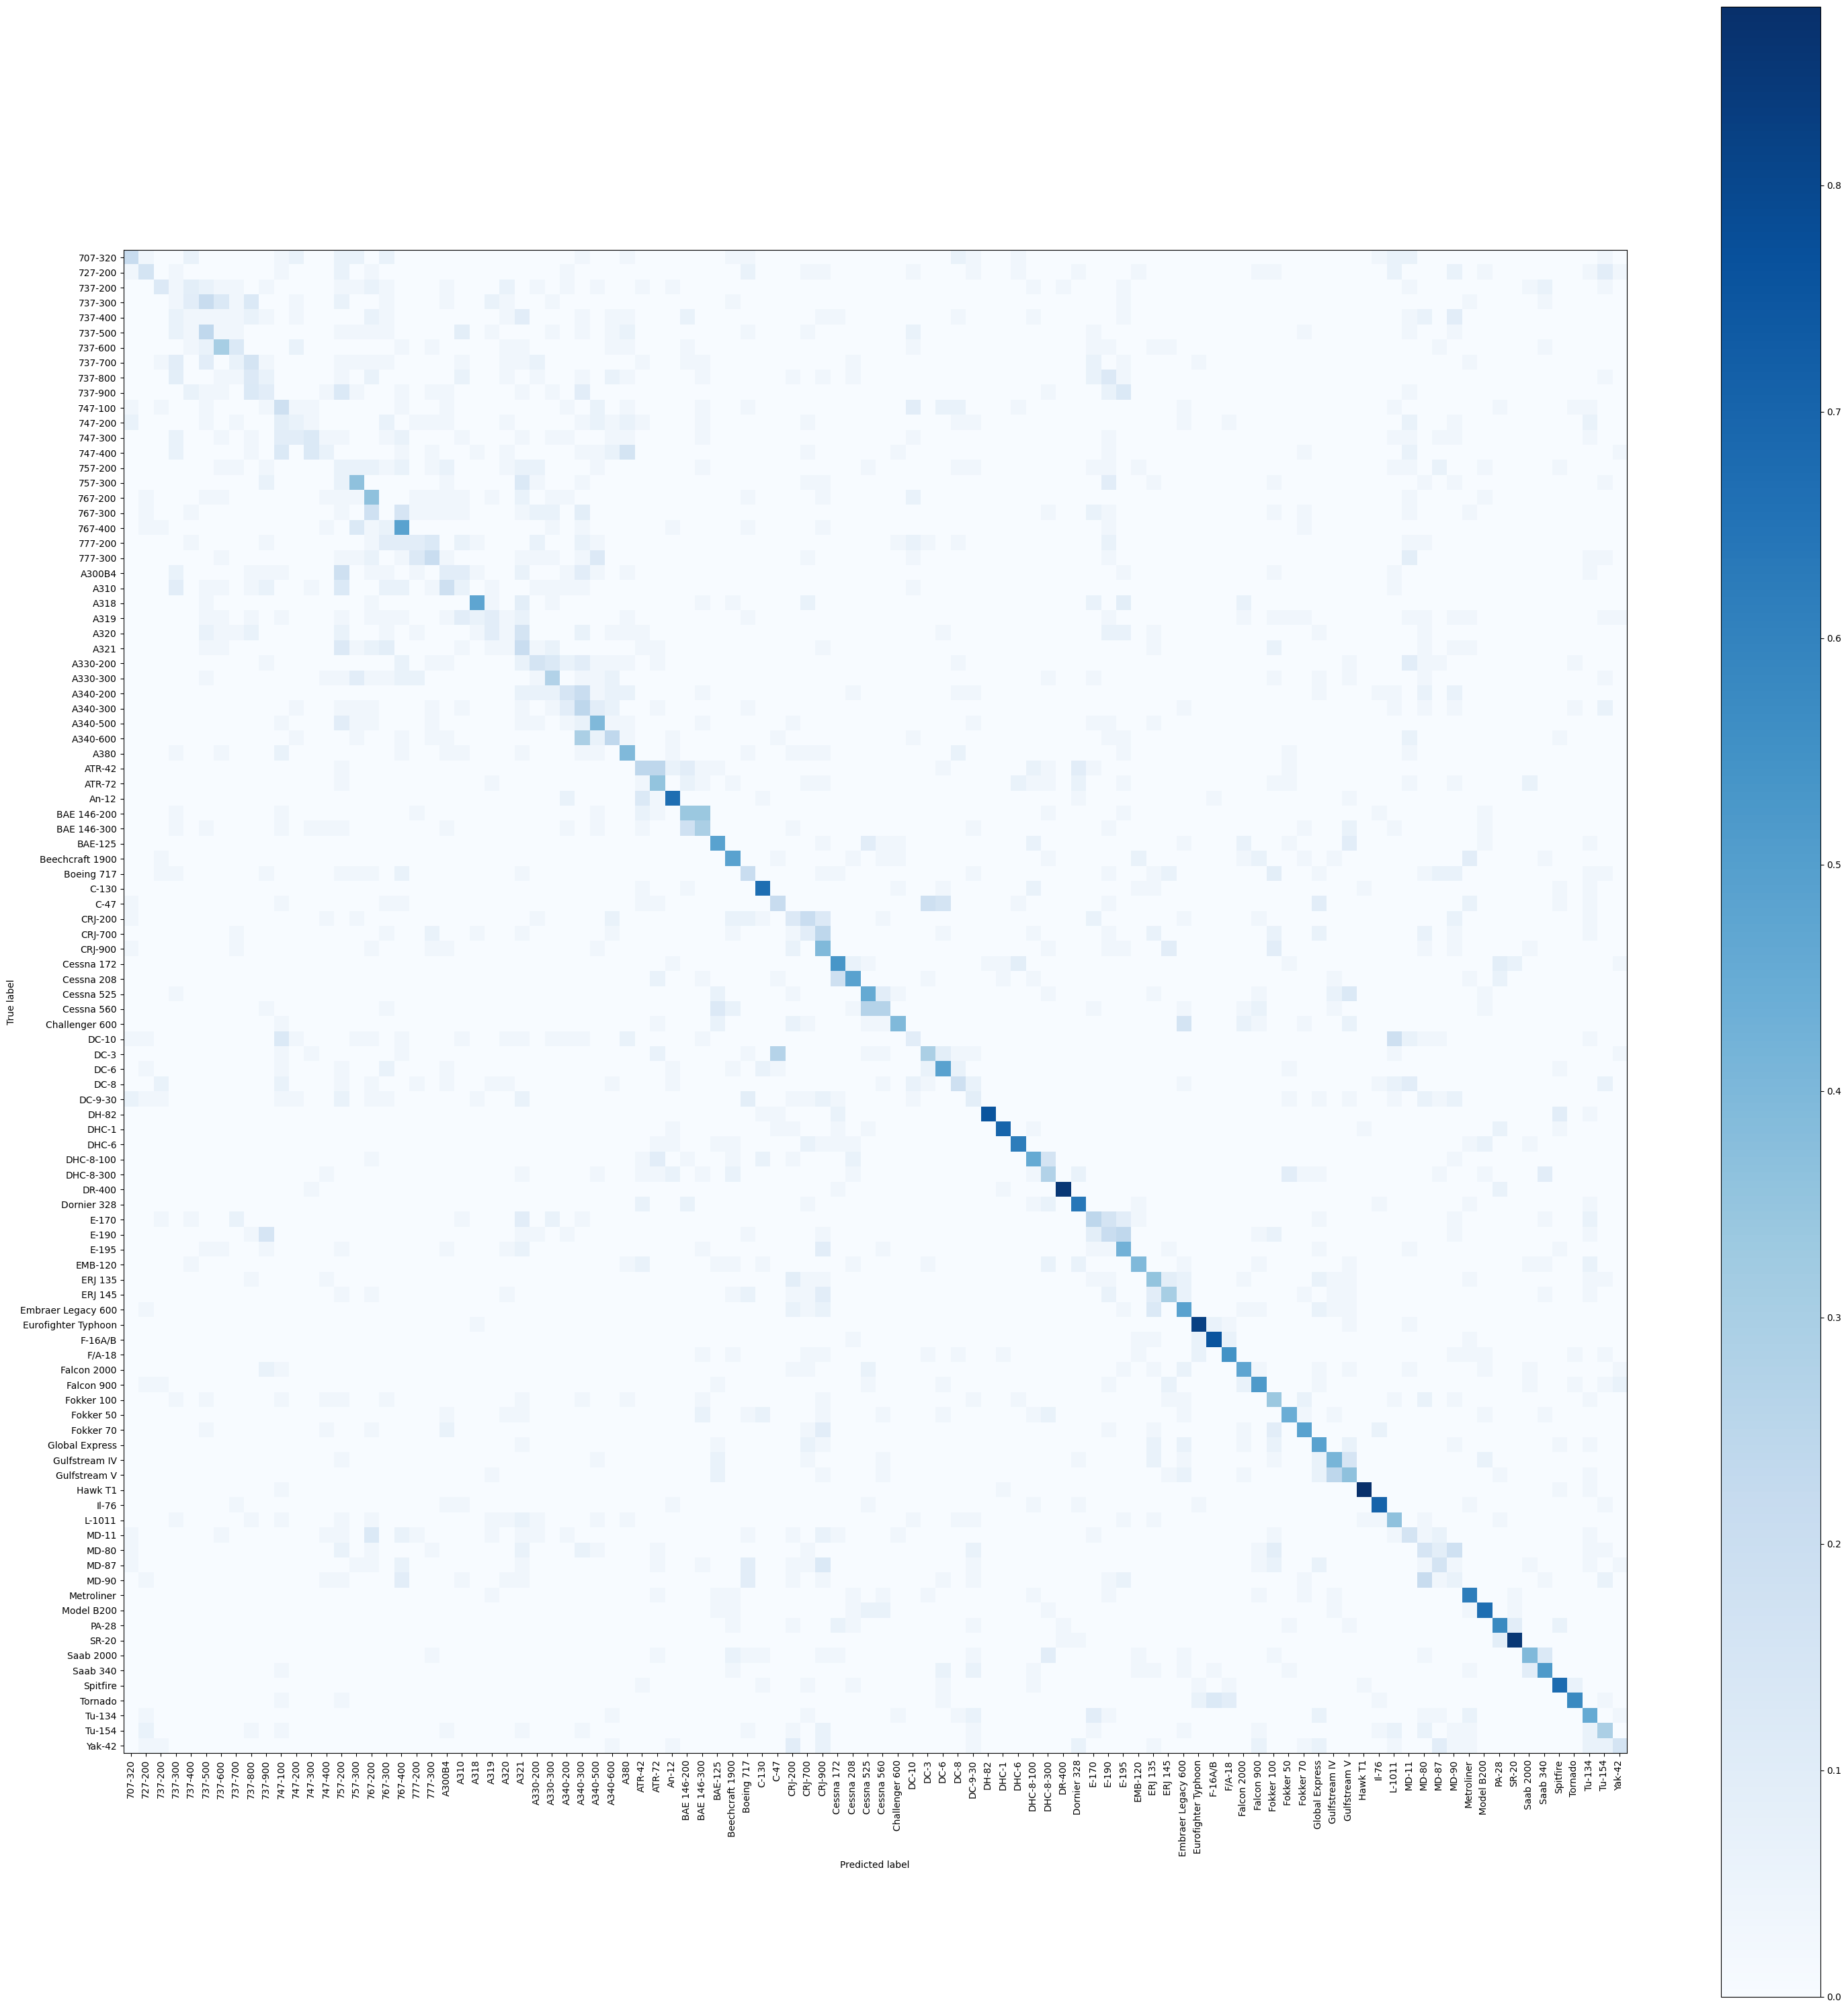

Best val acc = 0.344
Test acc = 0.345


,run_name,best_val_acc,test_acc,test_loss,best_epoch,augmentation,lr,head_lr,wd,dropout,label_smoothing,freeze_backbone,trainable_parameters
0,resnet18_same_hyperparameters_freeze_backbone,0.344434,0.345035,2.703389,68,light,0.003,None,0.0005,0.0,0.1,True,51300


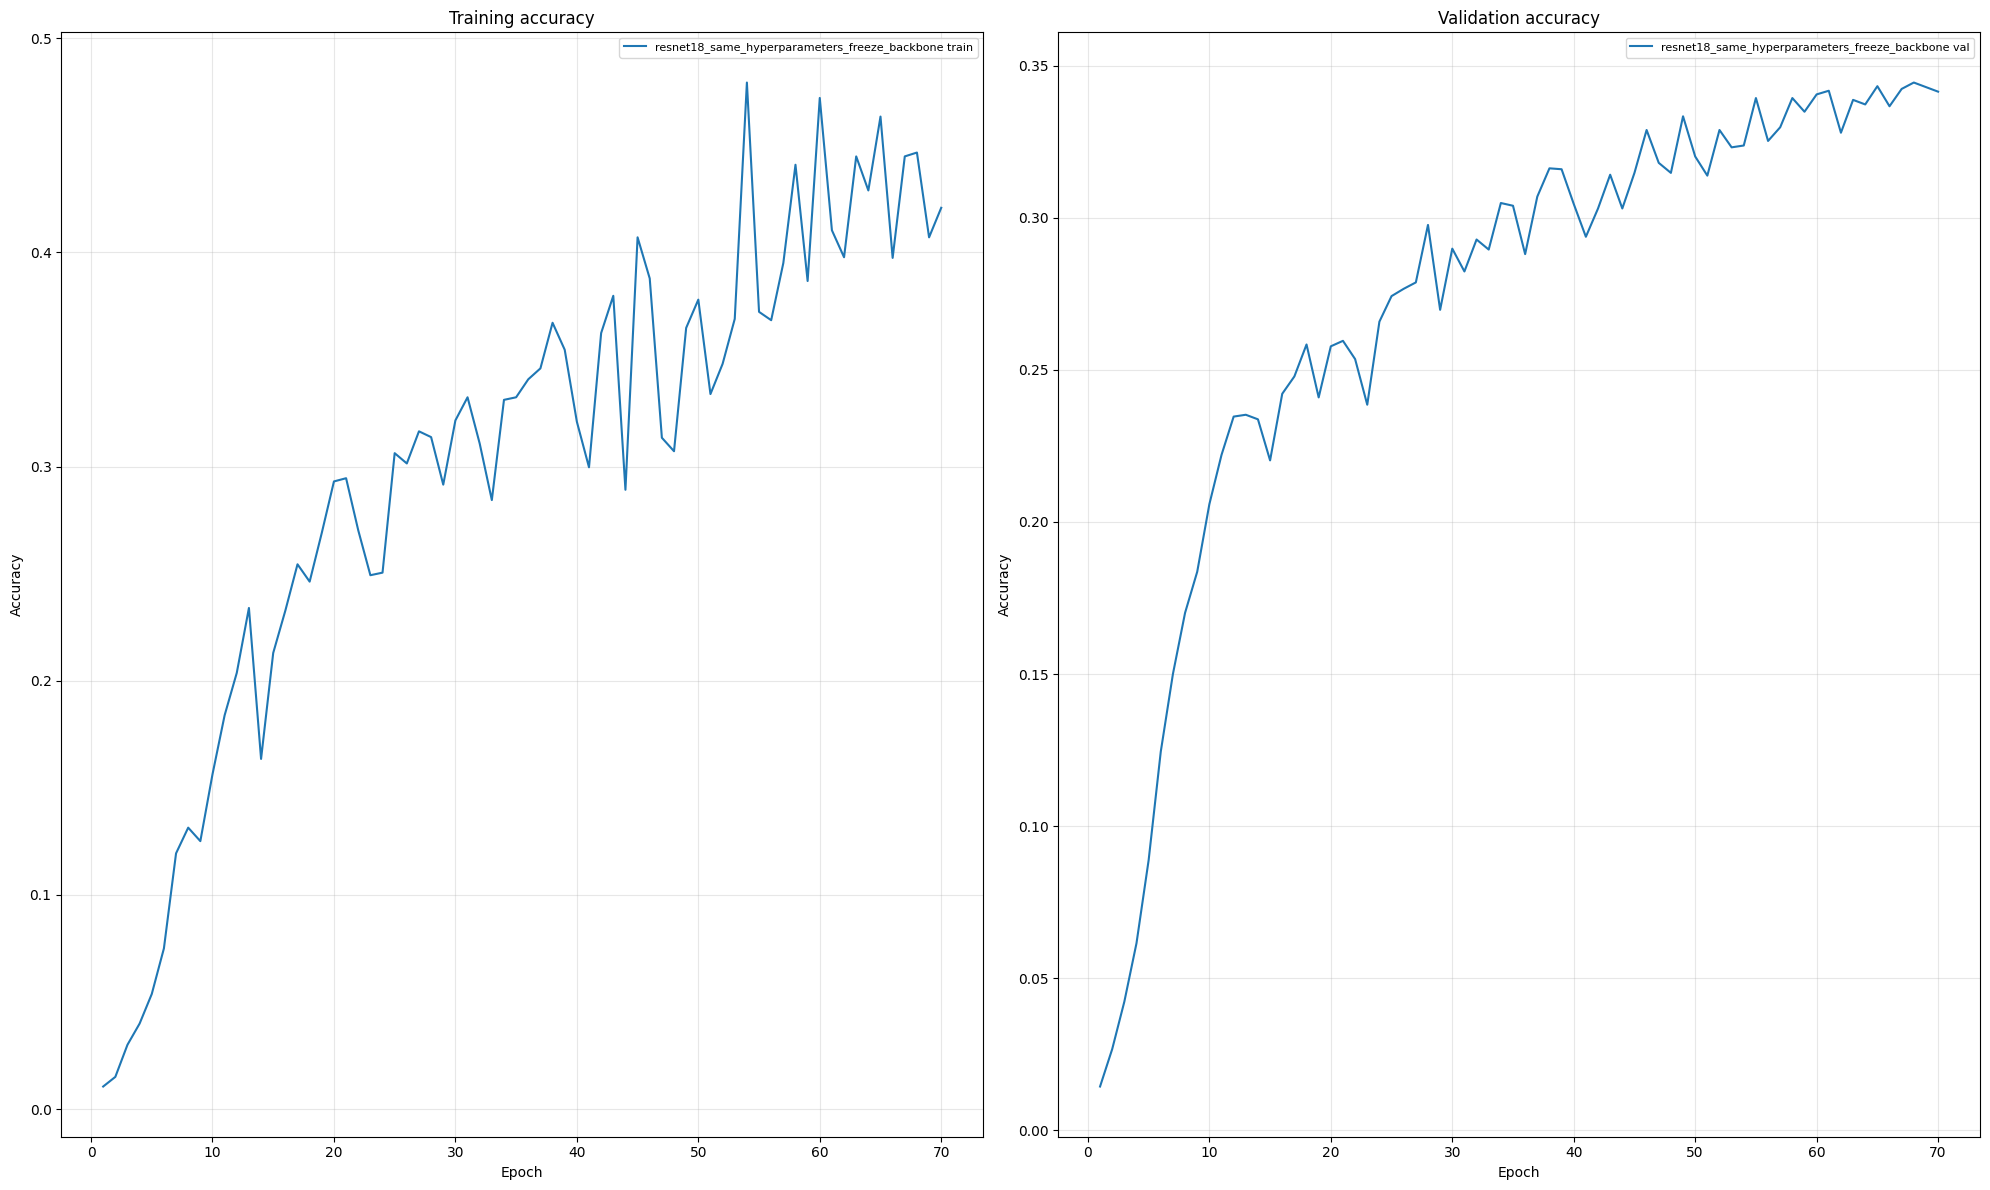

In [37]:
part2_results = {}

if RUN_TRAINING:
    part2_results[cfg_resnet_same_freeze["run_name"]] = run_experiment(cfg_resnet_same_freeze, get_resnet18_model)
    display(results_to_table(part2_results))
    plot_results(part2_results, save_path=path_plots / (cfg_resnet_same_freeze["run_name"] + ".png"))
else:
    print("RUN_TRAINING is False")


### Explanation of the results

### Train the whole model

In [44]:

cfg_resnet_same_whole = copy.deepcopy(cfg_part1)
cfg_resnet_same_whole["run_name"] = "resnet18_same_hyperparameters_whole_model"
cfg_resnet_same_whole["dropout"] = 0.0
cfg_resnet_same_whole["freeze_backbone"] = False
cfg_resnet_same_whole["early_stop_patience"] = 20
cfg_resnet_same_whole["head_lr"] = None

pd.DataFrame.from_dict(cfg_resnet_same_whole, orient="index", columns=["value"])

,value
resize_size,256
crop_size,224
image_size,224
augmentation,light
random_erasing,True
dropout,0.0
mixup_alpha,0.85
mixup_prob,0.75
label_smoothing,0.1
channels,"[32, 64, 128, 256]"


### Result

Run name = resnet18_same_hyperparameters_whole_model
Total parameters = 11,227,812
Trainable parameters = 11,227,812
Max learning rates for OneCycleLR: [0.003]


Epoch:   0%|          | 0/70 [00:00<?, ?it/s]


Training epoch 1/70


Epoch 1/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 001/70 | LR: 1.36e-04 | Train Loss: 4.4399 | Train Acc: 0.0585 | Val Loss: 3.6119 | Val Acc: 0.1956
✓ Saved new best model (val_acc=0.1956)

Training epoch 2/70


...

Epoch 69/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 069/70 | LR: 2.98e-06 | Train Loss: 1.6093 | Train Acc: 0.6323 | Val Loss: 1.3689 | Val Acc: 0.7174
Validation accuracy did not improve (4/20)

Training epoch 70/70


Epoch 70/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 070/70 | LR: 1.31e-08 | Train Loss: 1.7141 | Train Acc: 0.6428 | Val Loss: 1.3816 | Val Acc: 0.7165
Validation accuracy did not improve (5/20)

Training complete. Best validation accuracy: 0.7195 at epoch 65.
Best val acc = 0.719
Test acc = 0.721


,run_name,best_val_acc,test_acc,test_loss,best_epoch,augmentation,lr,head_lr,wd,dropout,label_smoothing,freeze_backbone,trainable_parameters
0,resnet18_same_hyperparameters_whole_model,0.719472,0.721272,1.330040,65,light,0.003,None,0.0005,0.0,0.1,False,11227812
1,resnet18_same_hyperparameters_freeze_backbone,0.344434,0.345035,2.703389,68,light,0.003,None,0.0005,0.0,0.1,True,51300


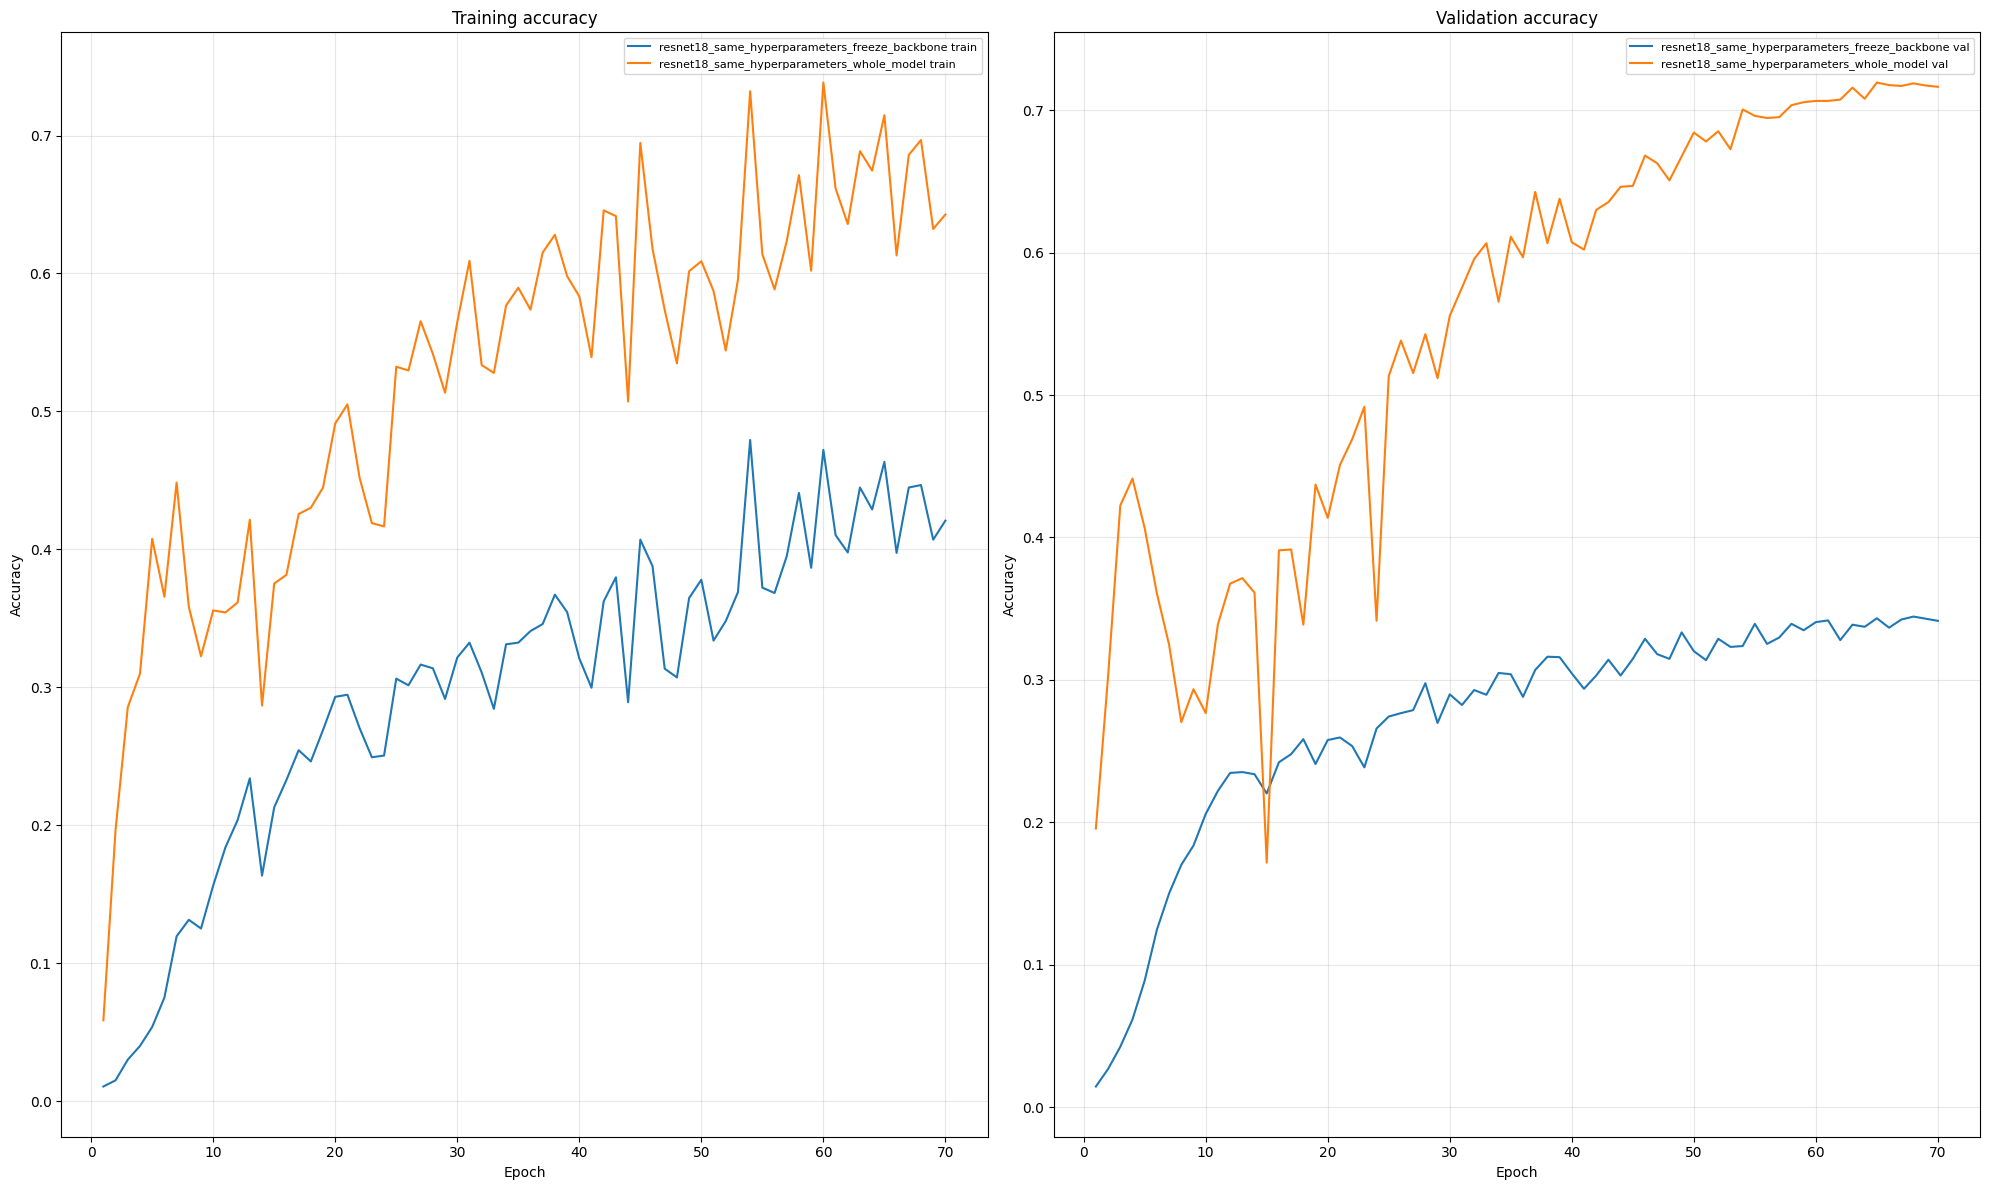

In [45]:
if RUN_TRAINING:
    part2_results[cfg_resnet_same_whole["run_name"]] = run_experiment(cfg_resnet_same_whole, get_resnet18_model)
    display(results_to_table(part2_results))
    plot_results(part2_results, save_path=path_plots / (cfg_resnet_same_whole["run_name"] + ".png"))
else:
    print("RUN_TRAINING is False")

### Explanation of the results

## Part 2B: full fine-tuning

After the  baseline, we will fine-tune all the hyper parmas


In [46]:
cfg_resnet_best = copy.deepcopy(cfg_resnet_same_freeze)
cfg_resnet_best["run_name"] = "resnet18_best"
cfg_resnet_best["augmentation"] = "light"
cfg_resnet_best["random_erasing"] = True
cfg_resnet_best["num_epochs"] = 70
cfg_resnet_best["lr"] = 1e-4
cfg_resnet_best["wd"] = 5e-4
cfg_resnet_best["head_lr"] = 1e-3
cfg_resnet_best["dropout"] = 0.15
cfg_resnet_best["mixup_alpha"] = 0.9
cfg_resnet_best["mixup_prob"] = 0.3
cfg_resnet_best["label_smoothing"] = 0.10
cfg_resnet_best["freeze_backbone"] = False

pd.DataFrame.from_dict(cfg_resnet_best, orient="index", columns=["value"])


,value
resize_size,256
crop_size,224
image_size,224
augmentation,light
random_erasing,True
dropout,0.15
mixup_alpha,0.9
mixup_prob,0.3
label_smoothing,0.1
channels,"[32, 64, 128, 256]"


### Results

In [ ]:

if RUN_TRAINING:
    part2_results[cfg_resnet_best["run_name"]] = run_experiment(cfg_resnet_best, get_resnet18_model)
    display(results_to_table(part2_results))
    plot_results(part2_results, save_path=path_plots / (cfg_resnet_best["run_name"] + ".png"))
else:
    print("RUN_TRAINING is False")

Run name = resnet18_best
Total parameters = 11,227,812
Trainable parameters = 11,227,812
Max learning rates for OneCycleLR: [0.0001, 0.001]


Epoch:   0%|          | 0/70 [00:00<?, ?it/s]


Training epoch 1/70


Epoch 1/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 001/70 | LR: 4.54e-06 | Train Loss: 4.7666 | Train Acc: 0.0123 | Val Loss: 4.6606 | Val Acc: 0.0120
✓ Saved new best model (val_acc=0.0120)

Training epoch 2/70


...

Epoch 19/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 019/70 | LR: 9.79e-05 | Train Loss: 1.8170 | Train Acc: 0.6977 | Val Loss: 1.5594 | Val Acc: 0.5893
✓ Saved new best model (val_acc=0.5893)

Training epoch 20/70


Epoch 20/70:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 020/70 | LR: 9.95e-05 | Train Loss: 1.4218 | Train Acc: 0.8152 | Val Loss: 1.5949 | Val Acc: 0.5875
Validation accuracy did not improve (1/12)

Training epoch 21/70


Epoch 21/70:   0%|          | 0/53 [00:00<?, ?it/s]

#### Explanation of the results

## Ablation study
In this section we will show how the performance of the best model drops when we remove some of its components. We will do this by running the same training procedure as before, but with different hyperparameters.
these hyperparameters are:

- freezing the backbone
- removing data augmentation
- make augmentation heavy
- removing mixup
- removing label smoothing
- removing dropout
- increasing the dropout
- changing the learning rate for head and backbone
- removing random erasing


And finally we will go through our journy of finding the best model with all of the running experiments and their results.
  

## Final comparison

The final table compares the custom CNN, the ablations, and the ResNet-18 experiments.


In [ ]:
all_results = {}
all_results.update(part1_results)
all_results.update(part2_results)

if len(all_results) > 0:
    table_all = results_to_table(all_results)
    table_all.to_csv(path_outputs / "final_model_comparison.csv", index=False)
    display(table_all)
    plot_results(all_results)
else:
    print("Run the training cells to populate the final comparison table.")


# Final remarks